# Drought Duration: Past, Present, and Future changes

In this tutorial, we explore how **drought duration** has changed over time and how it might change in the future for Central Greece (NUTS2 region EL64). This tutorial thus focuses on the **hazard** and how it changes under climate change.

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to analyze observed changes in drought duration using reanalysis data
- How climate models simulate historical droughts
- How to interpret future drought projections
- Why multiple climate models are essential for assessing uncertainty
- The importance of comparing projections to historical baselines
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for Central Greece (EL64). See the [How-To Guide on Drought Duration](../how-to-guides/drought_duration_ecde.ipynb) to process drought duration from the ECDE database. 
```

## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Settings

In [3]:
# Configuration
admin_id = 'EL64'

# Reference period (WMO standard: 1991-2020)
baseline_start = 1991
baseline_end = 2020

# Analysis settings
rolling_window = 30  # years for rolling mean

# Paths
workdir = Path("/home/nejk/code/drought_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id / 'drought_hazard'

# Load preprocessed data
reanalysis_file = data_dir / f'drought_duration_reanalysis_{admin_id}.csv'

proj_file = data_dir / f'drought_duration_projections_{admin_id}.csv'
print(f"Projection data: {proj_file}")

print(f"Region: {admin_id} (Central Greece)")
print(f"Reanalysis data: {reanalysis_file}")

Projection data: /home/nejk/code/drought_exposure/data/EL64/drought_hazard/drought_duration_projections_EL64.csv
Region: EL64 (Central Greece)
Reanalysis data: /home/nejk/code/drought_exposure/data/EL64/drought_hazard/drought_duration_reanalysis_EL64.csv


## Step 1: Observed Historical Change in Drought Duration

We begin by examining the **observed record** of drought duration using reanalysis data. Reanalyses combine historical observations with weather models to create a consistent, gridded dataset of past climate.

Let's load the historical data and visualize the trend:

In [4]:
# Load reanalysis data
reanalysis_df = pd.read_csv(reanalysis_file)
reanalysis_df['time'] = pd.to_datetime(reanalysis_df['time'])
reanalysis_df = reanalysis_df.sort_values('time')

print(f"Reanalysis data: {reanalysis_df['time'].min().year} to {reanalysis_df['time'].max().year}")
print(f"Number of years: {len(reanalysis_df)}")
reanalysis_df.head()

Reanalysis data: 1940 to 2023
Number of years: 84


,time,realization,nuts,dmd,scenario,model
0,1940-01-01,0,EL64,0.151107,reanalysis,reanalysis
1,1941-01-01,0,EL64,1.546539,reanalysis,reanalysis
2,1942-01-01,0,EL64,1.224761,reanalysis,reanalysis
3,1943-01-01,0,EL64,2.843414,reanalysis,reanalysis
4,1944-01-01,0,EL64,0.791908,reanalysis,reanalysis


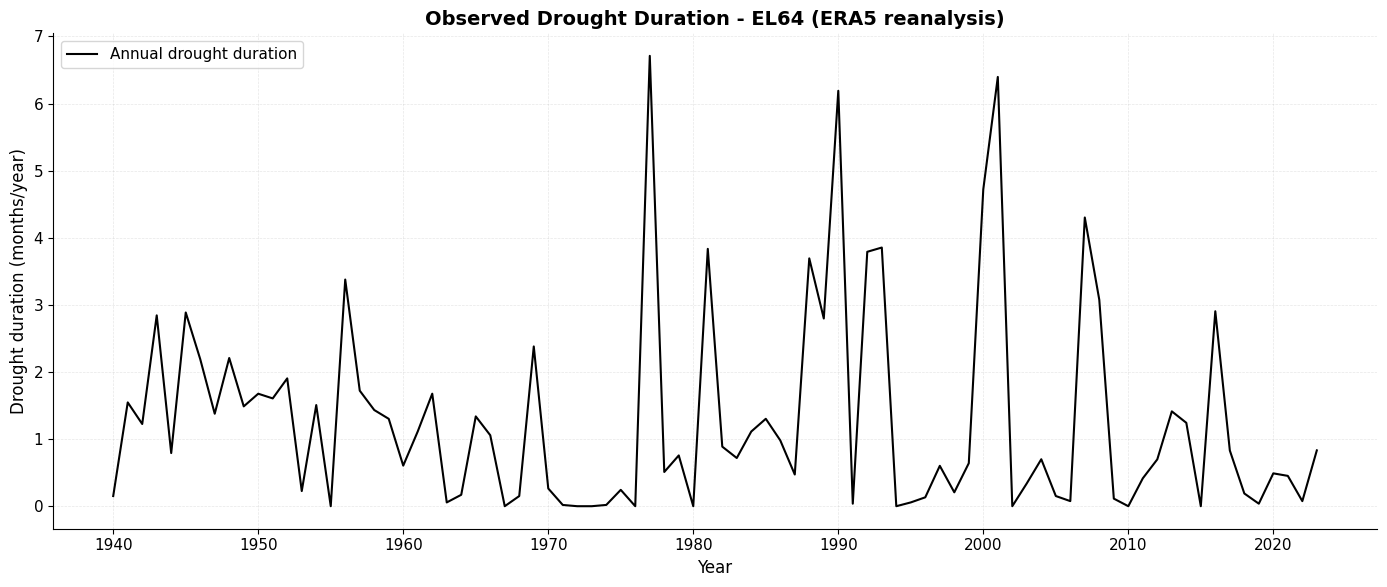


Observed drought duration statistics:
  Mean: 1.30 months/year
  Std: 1.54 months/year
  Min: 0.00 months/year (1955)
  Max: 6.71 months/year (1977)


In [5]:
# Plot observed drought duration
fig, ax = plt.subplots(figsize=(14, 6))

# Plot annual values
ax.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=1.5, label='Annual drought duration')


ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Observed Drought Duration - {admin_id} (ERA5 reanalysis)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate basic statistics
print(f"\nObserved drought duration statistics:")
print(f"  Mean: {reanalysis_df['dmd'].mean():.2f} months/year")
print(f"  Std: {reanalysis_df['dmd'].std():.2f} months/year")
print(f"  Min: {reanalysis_df['dmd'].min():.2f} months/year ({reanalysis_df.loc[reanalysis_df['dmd'].idxmin(), 'time'].year})")
print(f"  Max: {reanalysis_df['dmd'].max():.2f} months/year ({reanalysis_df.loc[reanalysis_df['dmd'].idxmax(), 'time'].year})")

## Step 2: Simulated Historical Change (Climate Models)

Now let's see how climate models simulate the same historical period. Climate models are our tools for understanding future climate, but first we need to check if they can reproduce the past.

We'll start by examining one climate model to understand the basics:

In [6]:
# Load projection data (includes historical model runs)
proj_df = pd.read_csv(proj_file)
proj_df['time'] = pd.to_datetime(proj_df['time'])
proj_df = proj_df.sort_values('time')

print(f"Projection data: {proj_df['time'].min().year} to {proj_df['time'].max().year}")
print(f"\nAvailable climate models: {proj_df['model'].nunique()}")
print(f"Available scenarios: {sorted(proj_df['scenario'].unique())}")

# Select one model for demonstration
example_model = 'mpi_esm_lr_cclm4_8_17_rcp4_5_r1i1p1'
print(f"\nExample model for demonstration: {example_model}")

Projection data: 1950 to 2100

Available climate models: 18
Available scenarios: ['RCP4_5', 'RCP8_5']

Example model for demonstration: mpi_esm_lr_cclm4_8_17_rcp4_5_r1i1p1


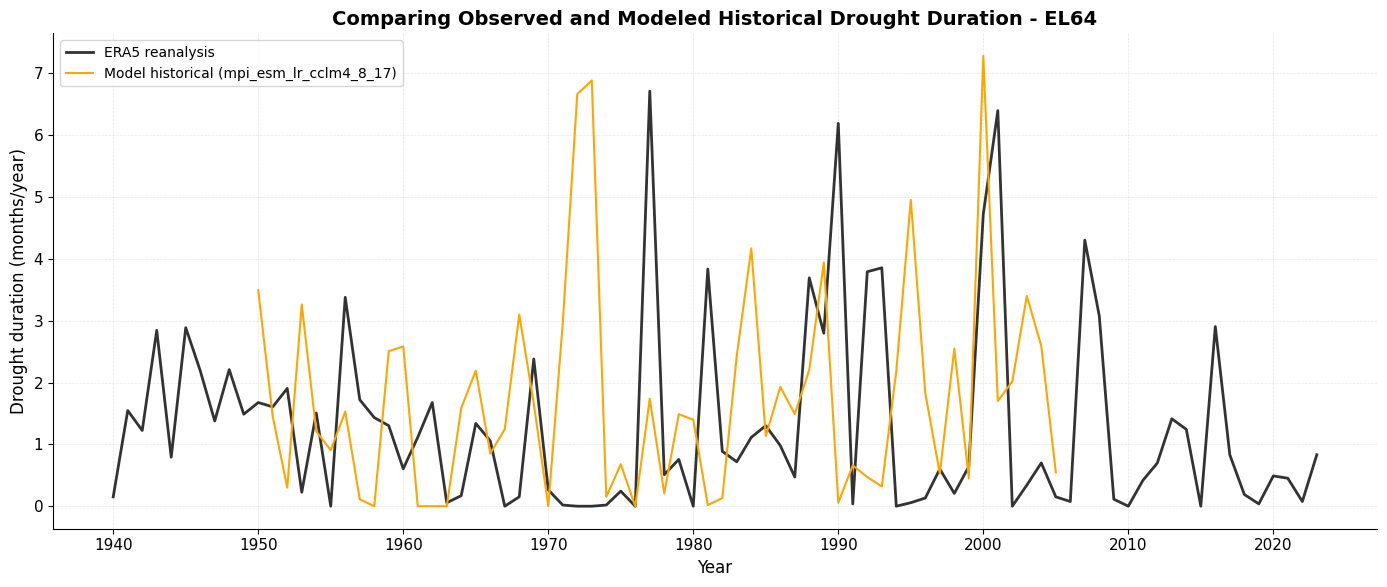


💡 Key Insight: Climate models simulate the historical period (1951-2005) to validate
   their ability to reproduce past climate before making future projections.


In [7]:
# Extract one model's data
model_df = proj_df[proj_df['model'] == example_model].copy()

# Split into historical and projection periods
hist_period = model_df[model_df['time'].dt.year <= 2005]
proj_period = model_df[model_df['time'].dt.year > 2005]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Reanalysis (observations)
ax.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Model historical period
ax.plot(hist_period['time'], hist_period['dmd'], 
        color='orange', linewidth=1.5, label=f'Model historical ({example_model.split("_rcp")[0]})', 
        linestyle='-', alpha=1)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Comparing Observed and Modeled Historical Drought Duration - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: Climate models simulate the historical period (1951-2005) to validate")
print(f"   their ability to reproduce past climate before making future projections.")

Even though the timeseries will never be identical and key drought events may appear at different times, the overall magnitude of drought events is similar. This is reassuring because we use bias-corrected projections in this example, so the climate model should have the same spread and mean as the reanalysis. We thus trust this model to roughly reproduce historical drought statistics. 

## Step 3: Projected Change in Drought Duration

Now we can look at future projections. Let's first see what one model projects for the future under a moderate emissions scenario (RCP4.5):

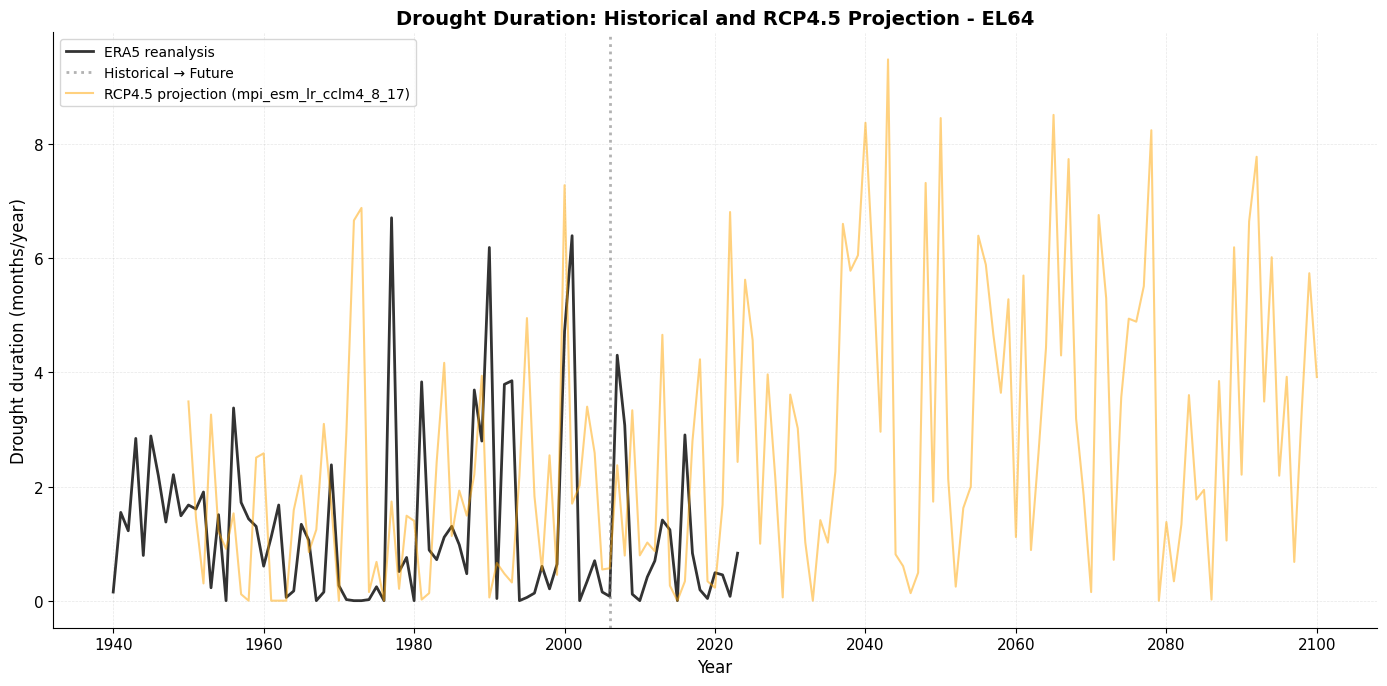


Projected change (2071-2100 vs 1991-2020):
  Baseline (1991-2020): 1.80 days/year
  Future (2071-2100): 3.58 days/year
  Change: +1.78 days/year (+98.5%)


In [17]:
# Get an example model
model_df = proj_df[proj_df['model'] == example_model].copy()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Plot reanalysis
ax.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Mark transition period
ax.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, label='Historical → Future', alpha=0.6)

# Plot projection
ax.plot(model_df['time'], model_df['dmd'], 
        color='orange', linewidth=1.5, label=f'RCP4.5 projection ({example_model.split("_rcp")[0]})', 
        alpha=0.5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Drought Duration: Historical and RCP4.5 Projection - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate change
baseline = model_df[model_df['time'].dt.year.between(baseline_start, baseline_end)]['dmd'].mean()
future = model_df[model_df['time'].dt.year.between(2071, 2100)]['dmd'].mean()
change = future - baseline

print(f"\nProjected change (2071-2100 vs {baseline_start}-{baseline_end}):")
print(f"  Baseline ({baseline_start}-{baseline_end}): {baseline:.2f} days/year")
print(f"  Future (2071-2100): {future:.2f} days/year")
print(f"  Change: {change:+.2f} days/year ({(change/baseline)*100:+.1f}%)")

### Best Practice 1: Using Multi-year Means


```{admonition} Why Multiple Years?
:class: important

```

Even within the reanalysis, we observe a strong natural variability between the years. In addition, we've already observed that the timing of the events differs between the reanalysis and the climate model, so we cannot project when and where droughts will occur — but we trust the climate model to capture mean drought duration over longer time periods. To account for the natural variability and this timing issue, we also calculate and plot the running mean over, e.g., 30 years of data. The length of this rolling window can be set at the very top of this tutorial, under `rolling_window = 30`. The running mean is shown as a thick lines in the plot below: 

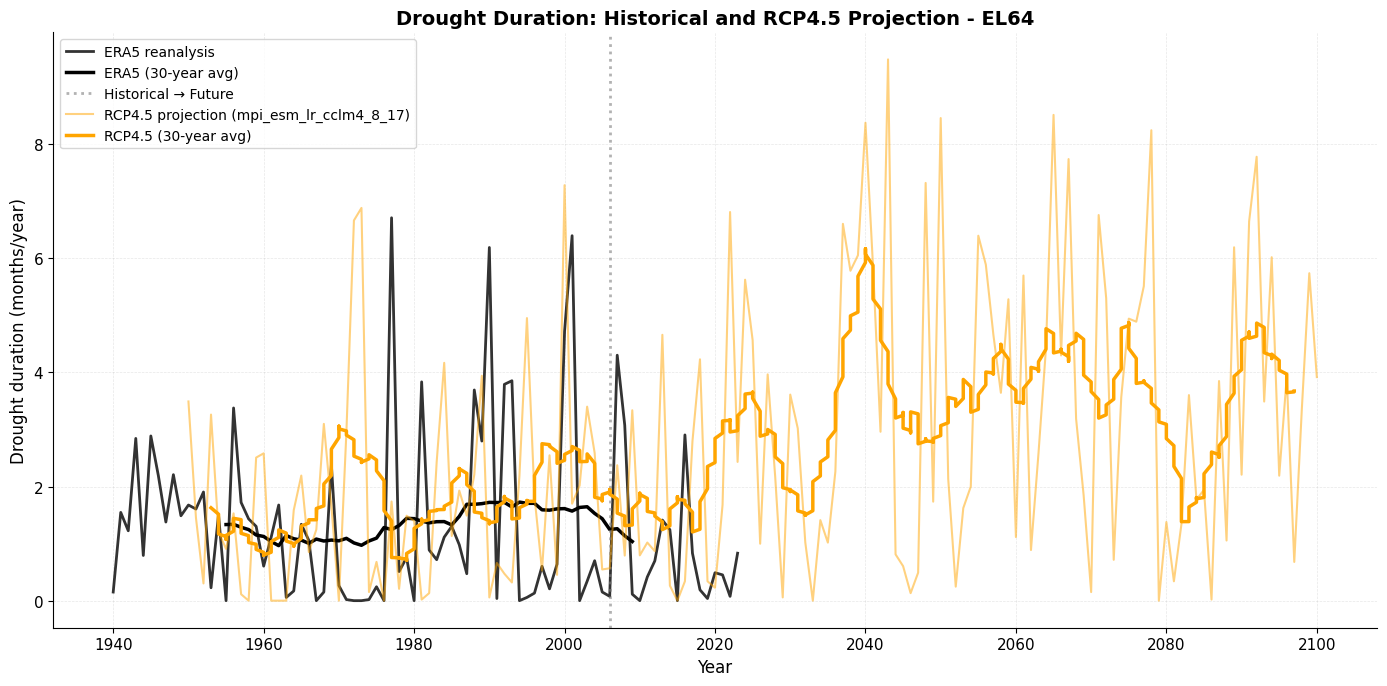


Projected change (2071-2100 vs 1991-2020):
  Baseline (1991-2020): 1.80 days/year
  Future (2071-2100): 3.58 days/year
  Change: +1.78 days/year (+98.5%)


In [20]:
# Get an example model
model_df = proj_df[proj_df['model'] == example_model].copy()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Plot reanalysis
ax.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Add 30-year rolling mean for reanlysis
rean_rolling = reanalysis_df.set_index('time')['dmd'].rolling(window=rolling_window, center=True).mean()
ax.plot(rean_rolling.index, rean_rolling.values, 
        color='black', linewidth=2.5, label=f'ERA5 ({rolling_window}-year avg)', alpha=1)

# Mark transition period
ax.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, label='Historical → Future', alpha=0.6)

# Plot projection
ax.plot(model_df['time'], model_df['dmd'], 
        color='orange', linewidth=1.5, label=f'RCP4.5 projection ({example_model.split("_rcp")[0]})', 
        alpha=0.5)

# Add 30-year rolling mean for projection
proj_rolling = model_df.set_index('time')['dmd'].rolling(window=rolling_window, center=True).mean()
ax.plot(proj_rolling.index, proj_rolling.values, 
        color='orange', linewidth=2.5, label=f'RCP4.5 ({rolling_window}-year avg)', alpha=1)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Drought Duration: Historical and RCP4.5 Projection - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate change
baseline = model_df[model_df['time'].dt.year.between(baseline_start, baseline_end)]['dmd'].mean()
future = model_df[model_df['time'].dt.year.between(2071, 2100)]['dmd'].mean()
change = future - baseline

print(f"\nProjected change (2071-2100 vs {baseline_start}-{baseline_end}):")
print(f"  Baseline ({baseline_start}-{baseline_end}): {baseline:.2f} days/year")
print(f"  Future (2071-2100): {future:.2f} days/year")
print(f"  Change: {change:+.2f} days/year ({(change/baseline)*100:+.1f}%)")

### Best Practice 2: Using Multiple Climate Models

```{admonition} Why Multiple Models?
:class: important
A single climate model gives us one possible future, but climate models have uncertainties. Using multiple models helps us understand the range of possible futures and assess the confidence in our projections.
```

Let's compare multiple climate models:

In [10]:
# Select RCP4.5 models
rcp45_df = proj_df[proj_df['scenario'] == 'RCP4_5'].copy()

# Get unique models
models = rcp45_df['model'].unique()
print(f"Number of RCP4.5 model combinations: {len(models)}")
print(f"\nModels included:")
for model in sorted(models):
    print(f"  - {model}")

Number of RCP4.5 model combinations: 9

Models included:
  - ec_earth_hirham5_rcp4_5_r3i1p1
  - ec_earth_racmo22e_rcp4_5_r1i1p1
  - ec_earth_rca4_rcp4_5_r12i1p1
  - hadgem2_es_racmo22e_rcp4_5_r1i1p1
  - hadgem2_es_rca4_rcp4_5_r1i1p1
  - ipsl_cm5a_mr_wrf381p_rcp4_5_r1i1p1
  - mpi_esm_lr_cclm4_8_17_rcp4_5_r1i1p1
  - mpi_esm_lr_rca4_rcp4_5_r1i1p1
  - noresm1_m_hirham5_rcp4_5_r1i1p1


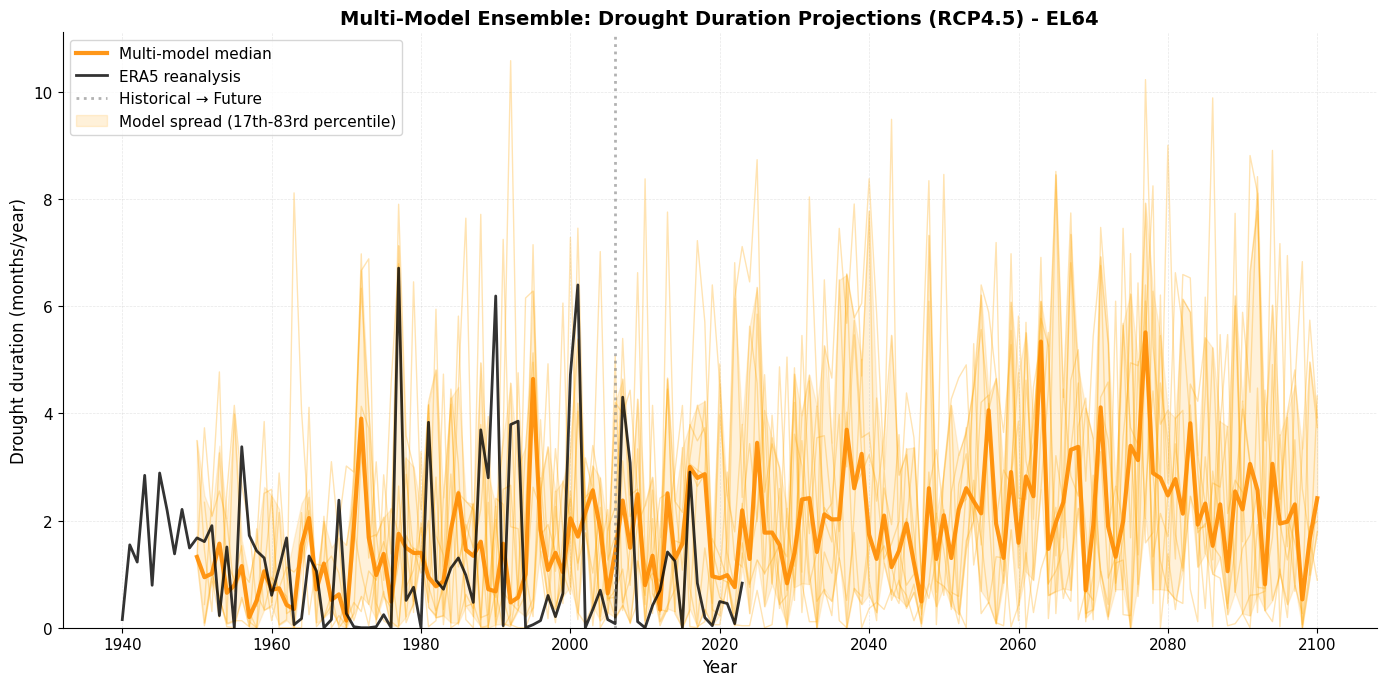


💡 Key Insight: The spread among models shows the uncertainty in projections.
   The multi-model median provides a more robust estimate than any single model.


In [11]:
# Plot all RCP4.5 models
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each model
for model in models:
    model_data = rcp45_df[rcp45_df['model'] == model]
    ax.plot(model_data['time'], model_data['dmd'], 
            linewidth=1, alpha=0.3, color='orange')

# Calculate and plot ensemble median
ensemble_median = rcp45_df.groupby('time')['dmd'].median().reset_index()
ax.plot(ensemble_median['time'], ensemble_median['dmd'], 
        color='darkorange', linewidth=3, label='Multi-model median', alpha=0.9)

# Add reanalysis for reference
ax.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Mark transition
ax.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, label='Historical → Future', alpha=0.6)

# Add shading for model spread
ensemble_p17 = rcp45_df.groupby('time')['dmd'].quantile(0.17).reset_index()
ensemble_p83 = rcp45_df.groupby('time')['dmd'].quantile(0.83).reset_index()
ensemble_data = ensemble_median.merge(ensemble_p17, on='time', suffixes=('_median', '_p17')).merge(ensemble_p83, on='time')
ax.fill_between(ensemble_data['time'], 
                ensemble_data['dmd_p17'],
                ensemble_data['dmd'],
                alpha=0.15, color='orange', label='Model spread (17th-83rd percentile)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Multi-Model Ensemble: Drought Duration Projections (RCP4.5) - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=0)  # Drought duration cannot be negative

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: The spread among models shows the uncertainty in projections.")
print(f"   The multi-model median provides a more robust estimate than any single model.")

### Best Practice 3: Comparing to Historical Baselines

```{admonition} Why Compare to Baselines?
:class: important
Climate change is measured as changes from a baseline period. The World Meteorological Organization (WMO) recommends using a 30-year baseline. The current WMO standard baseline is **1991-2020**, which accounts for natural climate variability.
```

The baseline period is set at the very beginning of the tutorial, as `baseline_start` and `baseline_end`. 
Let's calculate projected changes relative to this historical baseline:

In [12]:
# Define future periods for comparison
future_periods = {
    'Near-term (2021-2050)': (2021, 2050),
    'Mid-term (2041-2070)': (2041, 2070),
    'Long-term (2071-2100)': (2071, 2100)
}

# Calculate baseline from models (using projections, not reanalysis)
baseline_model = rcp45_df[
    rcp45_df['time'].dt.year.between(baseline_start, baseline_end)
].groupby('model')['dmd'].median()

print(f"Historical baseline ({baseline_start}-{baseline_end}):")
print(f"  Multi-model median: {baseline_model.median():.2f} (17th-83rd percentile: {baseline_model.quantile(0.17):.2f}-{baseline_model.quantile(0.83):.2f}) months/year")

# Calculate changes for each future period
print(f"\nProjected changes (RCP4.5) from baseline:")
for period_name, (start, end) in future_periods.items():
    future_vals = rcp45_df[
        rcp45_df['time'].dt.year.between(start, end)
    ].groupby('model')['dmd'].median()
    
    changes = future_vals - baseline_model
    
    print(f"\n  {period_name}:")
    print(f"    Median change: {changes.median():+.2f} months/year ({(changes.median()/baseline_model.median())*100:+.1f}%)")
    print(f"    Range: {changes.min():+.2f} to {changes.max():+.2f} months/year")
    print(f"    Agreement: {(changes > 0).sum()}/{len(changes)} models show increase")

Historical baseline (1991-2020):
  Multi-model median: 1.53 (17th-83rd percentile: 1.09-1.84) months/year

Projected changes (RCP4.5) from baseline:

  Near-term (2021-2050):
    Median change: +0.26 months/year (+17.2%)
    Range: -0.61 to +1.75 months/year
    Agreement: 6/9 models show increase

  Mid-term (2041-2070):
    Median change: +0.66 months/year (+43.3%)
    Range: -0.45 to +2.13 months/year
    Agreement: 7/9 models show increase

  Long-term (2071-2100):
    Median change: +0.74 months/year (+48.7%)
    Range: -0.46 to +2.64 months/year
    Agreement: 6/9 models show increase


And now let's create a visual comparison of the multi-model projected change in drought duration relative to the baseline:

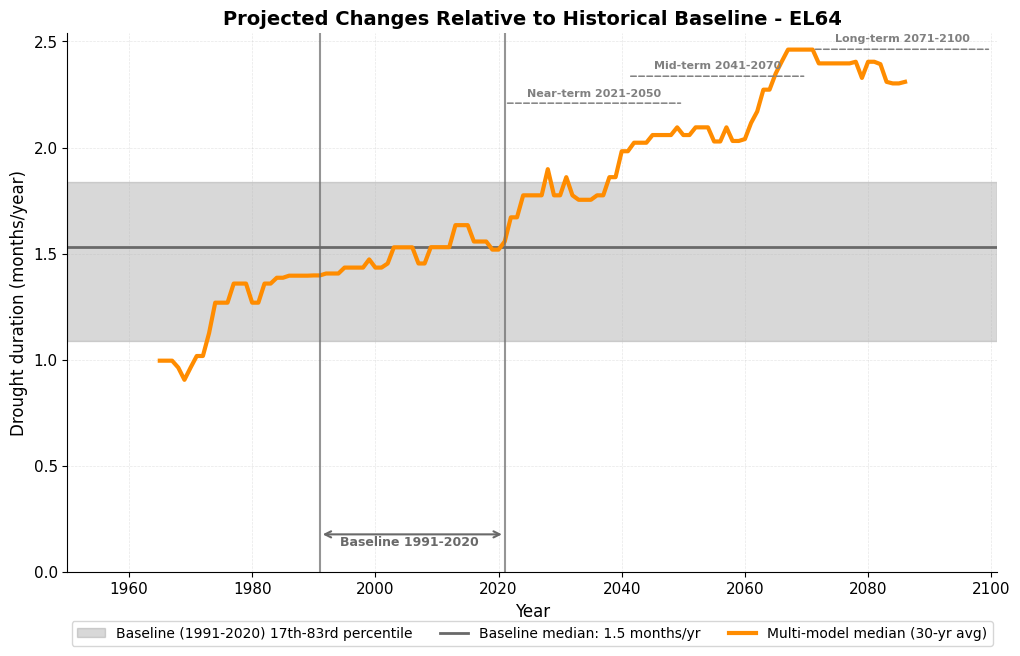

In [13]:
# Create a visual comparison
fig, ax = plt.subplots(figsize=(12, 7))

# Plot baseline period
baseline_median = baseline_model.median()
baseline_p17 = baseline_model.quantile(0.17)
baseline_p83 = baseline_model.quantile(0.83)
ax.axhspan(baseline_p17, baseline_p83,
           alpha=0.3, color='gray', label=f'Baseline ({baseline_start}-{baseline_end}) 17th-83rd percentile')
ax.axhline(baseline_median, color='dimgray', linestyle='-', linewidth=2, 
          label=f'Baseline median: {baseline_median:.1f} months/yr')

# Plot multi-model ensemble median with rolling average
ensemble_rolling = ensemble_median.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()
ax.plot(ensemble_rolling.index, ensemble_rolling.values, 
        color='darkorange', linewidth=3, label=f'Multi-model median ({rolling_window}-yr avg)')

# Set x-axis limits to extend to 2100
ax.set_xlim(left=pd.Timestamp('1950-01-01'), right=pd.Timestamp('2100-12-31'))

# Set y-axis limit first to ensure consistent positioning
ax.set_ylim(bottom=0)  # Drought duration cannot be negative

# baseline: mark baseline period with vertical bars
ax.axvline(pd.Timestamp(f'{baseline_start}-01-01'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(pd.Timestamp(f'{baseline_end}-12-31'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
# baseline: add horizontal arrow showing baseline extent at bottom
y_min = ax.get_ylim()[0]
y_max = ax.get_ylim()[1]
y_bottom = y_min + (y_max - y_min) * 0.07
baseline_mid = baseline_start + (baseline_end - baseline_start) // 2
ax.annotate('', xy=(pd.Timestamp(f'{baseline_end}-12-31'), y_bottom), 
            xytext=(pd.Timestamp(f'{baseline_start}-01-01'), y_bottom),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax.text(pd.Timestamp(f'{baseline_mid}-06-30'), y_bottom * 0.95, f'Baseline {baseline_start}-{baseline_end}', 
        ha='center', va='top', fontsize=9, color='dimgray', fontweight='bold')

# projections: mark future periods with horizontal arrows at different heights (reversed order: long-term highest)
ax.set_xlim(left=pd.Timestamp('1950-01-01'), right=pd.Timestamp('2100-12-31'))
period_info = [
    ('2071-01-01', '2099-12-31', 'Long-term 2071-2100', 0.97),
    ('2041-01-01', '2069-12-31', 'Mid-term 2041-2070', 0.92),
    ('2021-01-01', '2049-12-31', 'Near-term 2021-2050', 0.87)
]
for start_date, end_date, label, height_factor in period_info:
    y_pos = y_max * height_factor
    ax.annotate('', xy=(pd.Timestamp(end_date), y_pos), 
                xytext=(pd.Timestamp(start_date), y_pos),
                arrowprops=dict(arrowstyle='-', color='gray', lw=1.1, linestyle='--'))
    # Calculate midpoint for text
    mid_date = pd.Timestamp(start_date) + (pd.Timestamp(end_date) - pd.Timestamp(start_date)) / 2
    ax.text(mid_date, y_pos * 1.01, label, 
            ha='center', va='bottom', fontsize=8, color='gray', fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Projected Changes Relative to Historical Baseline - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#plt.tight_layout()
plt.show()


## Comparing Emission Scenarios

### Best Practice 4: Consider different emission scenarios

```{admonition} Why should we use multiple emission scenarios?
:class: important
...
```

Finally, let's compare different emission scenarios (RCP4.5 and RCP8.5) to understand how different levels of greenhouse gas emissions could affect future drought duration:

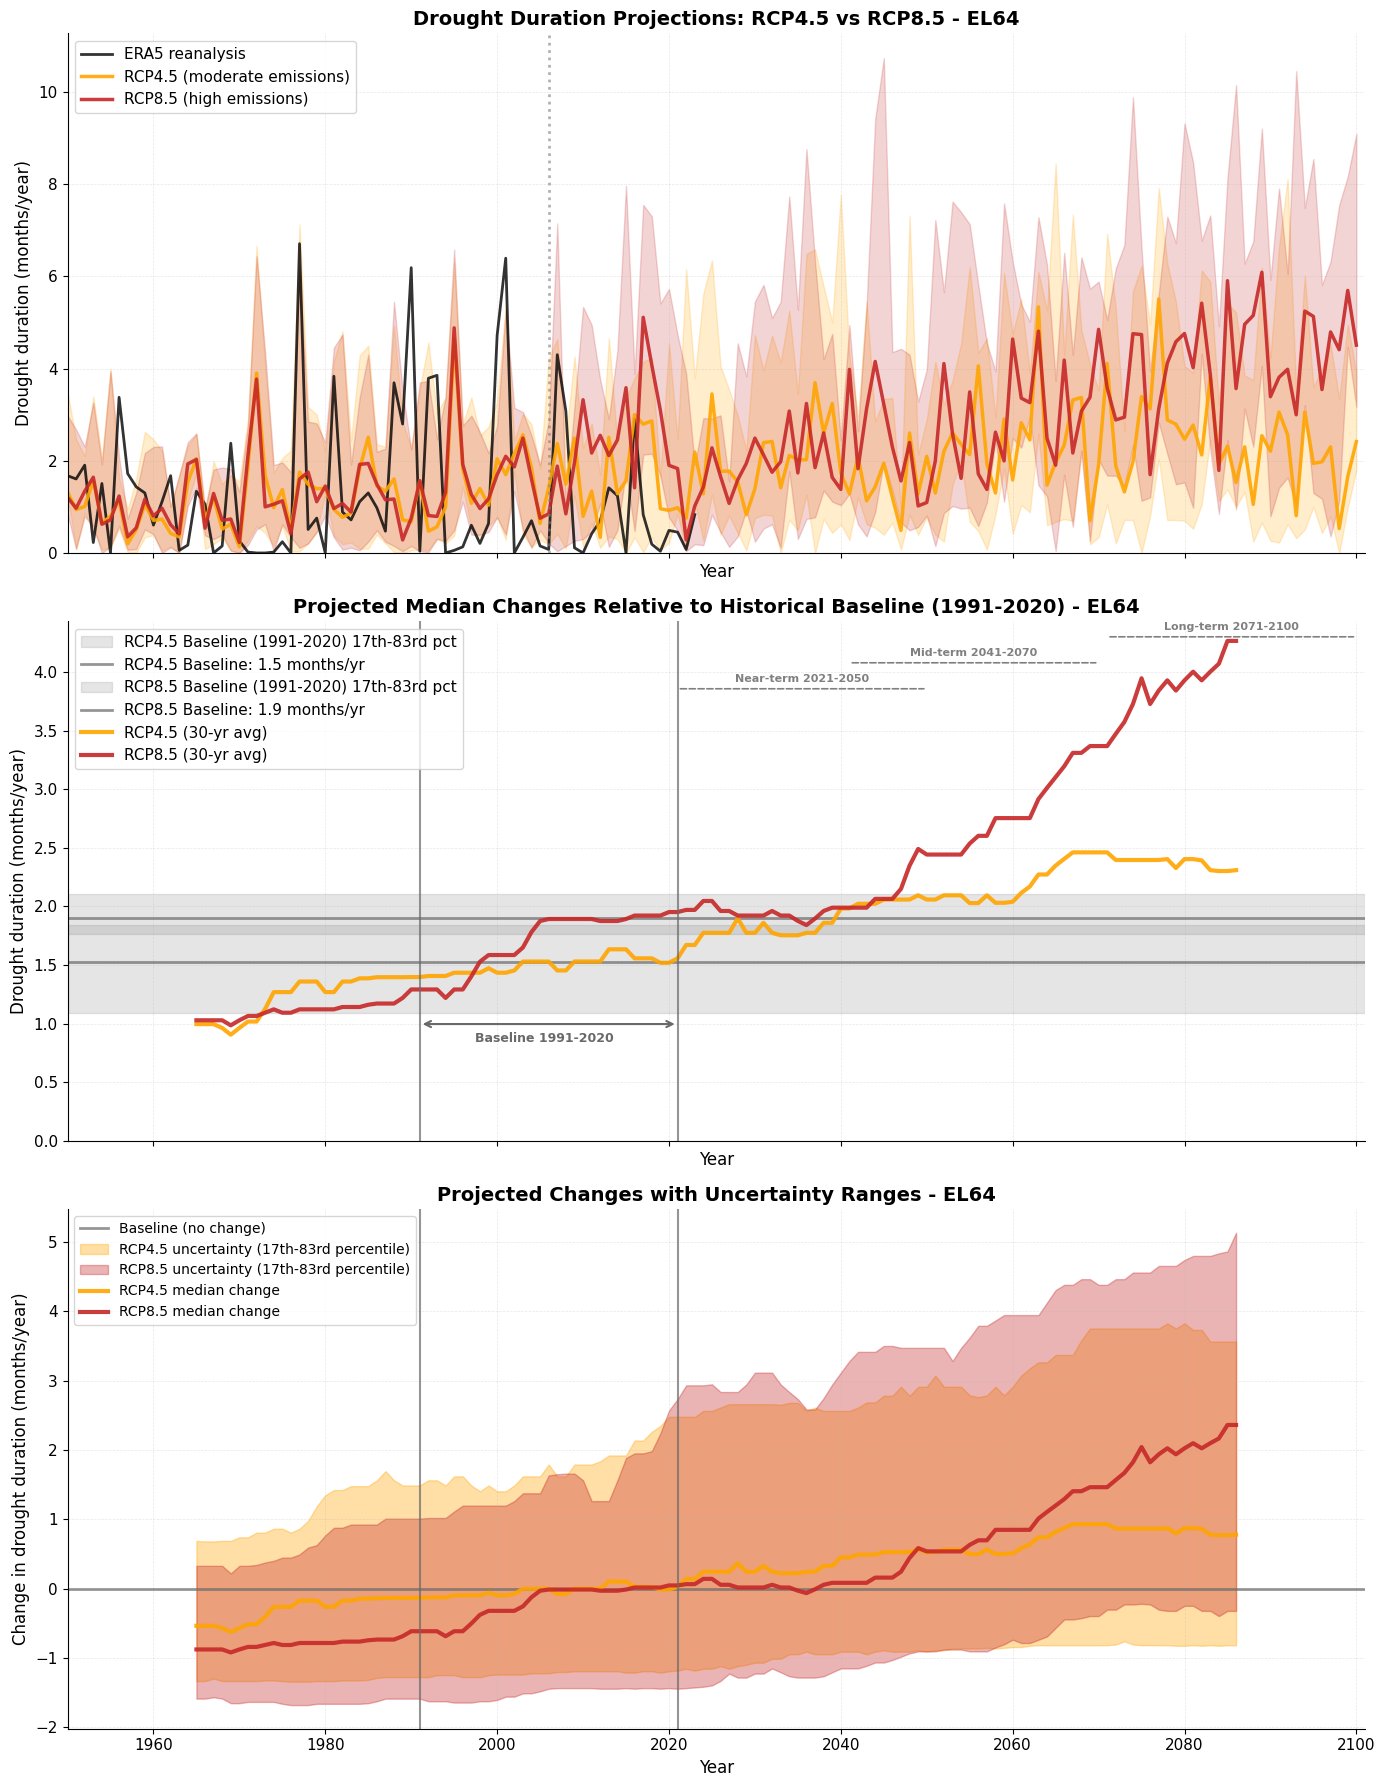


End of century (2071-2100) comparison:
  RCP4.5: 2.48 (17th-83rd pct: 1.48-3.34) months/year
    Change from baseline: +0.95 months/year (+62.2%)
  RCP8.5: 4.53 (17th-83rd pct: 3.39-5.17) months/year
    Change from baseline: +2.62 months/year (+137.8%)
  Difference between scenarios: 2.05 months/year

💡 Key Insight: Higher emissions (RCP8.5) lead to longer lasting droughts.
   Mitigation efforts (RCP4.5) can reduce future drought risk.


In [14]:
# Prepare data for both scenarios
rcp85_df = proj_df[proj_df['scenario'] == 'RCP8_5'].copy()

# Calculate ensemble medians for both scenarios
rcp45_median = rcp45_df.groupby('time')['dmd'].median().reset_index()
rcp85_median = rcp85_df.groupby('time')['dmd'].median().reset_index()

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# ========== Top plot: Scenario comparison ==========
# Reanalysis
ax1.plot(reanalysis_df['time'], reanalysis_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# RCP4.5
ax1.plot(rcp45_median['time'], rcp45_median['dmd'], 
        color='orange', linewidth=2.5, label='RCP4.5 (moderate emissions)', alpha=0.9)

# RCP8.5
ax1.plot(rcp85_median['time'], rcp85_median['dmd'], 
        color='#c62828', linewidth=2.5, label='RCP8.5 (high emissions)', alpha=0.9)

# Add spread for both scenarios
rcp45_p17 = rcp45_df.groupby('time')['dmd'].quantile(0.17).reset_index()
rcp45_p83 = rcp45_df.groupby('time')['dmd'].quantile(0.83).reset_index()
rcp85_p17 = rcp85_df.groupby('time')['dmd'].quantile(0.17).reset_index()
rcp85_p83 = rcp85_df.groupby('time')['dmd'].quantile(0.83).reset_index()

ax1.fill_between(rcp45_median['time'], 
                rcp45_p17['dmd'],
                rcp45_p83['dmd'],
                alpha=0.2, color='orange')

ax1.fill_between(rcp85_median['time'], 
                rcp85_p17['dmd'],
                rcp85_p83['dmd'],
                alpha=0.2, color='#c62828')

# Mark transition
ax1.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, alpha=0.6)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylim(bottom=0)  # Drought duration cannot be negative
ax1.set_ylabel('Drought duration (months/year)', fontsize=12)
ax1.set_title(f'Drought Duration Projections: RCP4.5 vs RCP8.5 - {admin_id}', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11, frameon=True)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ========== Middle plot: Changes relative to baseline ==========
# Calculate baseline from both scenarios
baseline_rcp45 = rcp45_df[
    rcp45_df['time'].dt.year.between(baseline_start, baseline_end)
].groupby('model')['dmd'].median()

baseline_rcp85 = rcp85_df[
    rcp85_df['time'].dt.year.between(baseline_start, baseline_end)
].groupby('model')['dmd'].median()

# Plot RCP4.5 baseline period (grey theme)
ax2.axhspan(baseline_rcp45.quantile(0.17), baseline_rcp45.quantile(0.83),
           alpha=0.2, color='gray', label=f'RCP4.5 Baseline ({baseline_start}-{baseline_end}) 17th-83rd pct')
ax2.axhline(baseline_rcp45.median(), color='dimgray', linestyle='-', linewidth=2, alpha=0.7,
          label=f'RCP4.5 Baseline: {baseline_rcp45.median():.1f} months/yr')

# Plot RCP8.5 baseline period (grey theme)
ax2.axhspan(baseline_rcp85.quantile(0.17), baseline_rcp85.quantile(0.83),
           alpha=0.2, color='gray', label=f'RCP8.5 Baseline ({baseline_start}-{baseline_end}) 17th-83rd pct')
ax2.axhline(baseline_rcp85.median(), color='dimgray', linestyle='-', linewidth=2, alpha=0.7,
          label=f'RCP8.5 Baseline: {baseline_rcp85.median():.1f} months/yr')

# Plot ensemble medians with rolling average
rcp45_rolling = rcp45_median.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()
rcp85_rolling = rcp85_median.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()

# Calculate rolling percentiles for uncertainty bands
rcp45_p17_rolling = rcp45_p17.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()
rcp45_p83_rolling = rcp45_p83.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()
rcp85_p17_rolling = rcp85_p17.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()
rcp85_p83_rolling = rcp85_p83.set_index('time')['dmd'].rolling(window=rolling_window, center=True).median()

# Plot median lines
ax2.plot(rcp45_rolling.index, rcp45_rolling.values, 
        color='orange', linewidth=3, label=f'RCP4.5 ({rolling_window}-yr avg)', alpha=0.9)
ax2.plot(rcp85_rolling.index, rcp85_rolling.values, 
        color='#c62828', linewidth=3, label=f'RCP8.5 ({rolling_window}-yr avg)', alpha=0.9)

# baseline: mark baseline period with vertical bars
ax2.axvline(pd.Timestamp(f'{baseline_start}-01-01'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
ax2.axvline(pd.Timestamp(f'{baseline_end}-12-31'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
# baseline: add horizontal arrow showing baseline extent at bottom
y_min = ax2.get_ylim()[0]
y_bottom = y_min + (ax2.get_ylim()[1] - y_min) * 0.07
baseline_mid = baseline_start + (baseline_end - baseline_start) // 2
ax2.annotate('', xy=(pd.Timestamp(f'{baseline_end}-12-31'), y_bottom), 
            xytext=(pd.Timestamp(f'{baseline_start}-01-01'), y_bottom),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax2.text(pd.Timestamp(f'{baseline_mid}-06-30'), y_bottom * 0.93, f'Baseline {baseline_start}-{baseline_end}', 
        ha='center', va='top', fontsize=9, color='dimgray', fontweight='bold')

# projections: mark future periods with horizontal arrows at different heights (reversed order: long-term highest)
period_info = [
    ('2071-01-01', '2099-12-31', 'Long-term 2071-2100', 0.97),
    ('2041-01-01', '2069-12-31', 'Mid-term 2041-2070', 0.92),
    ('2021-01-01', '2049-12-31', 'Near-term 2021-2050', 0.87)
]

y_max = ax2.get_ylim()[1]
for start_date, end_date, label, height_factor in period_info:
    y_pos = y_max * height_factor
    ax2.annotate('', xy=(pd.Timestamp(end_date), y_pos), 
                xytext=(pd.Timestamp(start_date), y_pos),
                arrowprops=dict(arrowstyle='-', color='gray', lw=1.2, linestyle='--'))
    # Calculate midpoint for text
    mid_date = pd.Timestamp(start_date) + (pd.Timestamp(end_date) - pd.Timestamp(start_date)) / 2
    ax2.text(mid_date, y_pos * 1.01, label, 
            ha='center', va='bottom', fontsize=8, color='gray', fontweight='bold')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Drought duration (months/year)', fontsize=12)
ax2.set_title(f'Projected Median Changes Relative to Historical Baseline ({baseline_start}-{baseline_end}) - {admin_id}', 
             fontsize=14, fontweight='bold')
ax2.set_ylim(bottom=0)  # Drought duration cannot be negative
# Set x-axis limits to extend to 2100
ax2.set_xlim(left=pd.Timestamp('1950-01-01'), right=pd.Timestamp('2100-12-31'))
ax2.legend(loc='upper left', fontsize=11, frameon=True)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ========== Bottom plot: Uncertainty bands (percentiles) ==========
# Plot baseline reference line at zero change
ax3.axhline(0, color='dimgray', linestyle='-', linewidth=2, alpha=0.7, label='Baseline (no change)')

# Plot percentile bands showing range of projected change
ax3.fill_between(rcp45_rolling.index, 
                rcp45_p17_rolling.values - baseline_rcp45.median(),
                rcp45_p83_rolling.values - baseline_rcp45.median(),
                alpha=0.35, color='orange', label=f'RCP4.5 uncertainty (17th-83rd percentile)')
ax3.fill_between(rcp85_rolling.index, 
                rcp85_p17_rolling.values - baseline_rcp85.median(),
                rcp85_p83_rolling.values - baseline_rcp85.median(),
                alpha=0.35, color='#c62828', label=f'RCP8.5 uncertainty (17th-83rd percentile)')

# Plot median change
rcp45_change = rcp45_rolling.values - baseline_rcp45.median()
rcp85_change = rcp85_rolling.values - baseline_rcp85.median()
ax3.plot(rcp45_rolling.index, rcp45_change, 
        color='orange', linewidth=3, label=f'RCP4.5 median change', alpha=0.9)
ax3.plot(rcp85_rolling.index, rcp85_change, 
        color='#c62828', linewidth=3, label=f'RCP8.5 median change', alpha=0.9)

# Mark baseline period with vertical bars
ax3.axvline(pd.Timestamp(f'{baseline_start}-01-01'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
ax3.axvline(pd.Timestamp(f'{baseline_end}-12-31'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)

ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Change in drought duration (months/year)', fontsize=12)
ax3.set_title(f'Projected Changes with Uncertainty Ranges - {admin_id}', 
             fontsize=14, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10, frameon=True)
ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate end-of-century differences (relative to each scenario's own baseline)
eoc_45 = rcp45_df[rcp45_df['time'].dt.year.between(2071, 2100)].groupby('model')['dmd'].median()
eoc_85 = rcp85_df[rcp85_df['time'].dt.year.between(2071, 2100)].groupby('model')['dmd'].median()

# Calculate changes from baseline
change_45 = eoc_45.median() - baseline_rcp45.median()
change_85 = eoc_85.median() - baseline_rcp85.median()

print(f"\nEnd of century (2071-2100) comparison:")
print(f"  RCP4.5: {eoc_45.median():.2f} (17th-83rd pct: {eoc_45.quantile(0.17):.2f}-{eoc_45.quantile(0.83):.2f}) months/year")
print(f"    Change from baseline: {change_45:+.2f} months/year ({(change_45/baseline_rcp45.median())*100:+.1f}%)")
print(f"  RCP8.5: {eoc_85.median():.2f} (17th-83rd pct: {eoc_85.quantile(0.17):.2f}-{eoc_85.quantile(0.83):.2f}) months/year")
print(f"    Change from baseline: {change_85:+.2f} months/year ({(change_85/baseline_rcp85.median())*100:+.1f}%)")
print(f"  Difference between scenarios: {(eoc_85.median() - eoc_45.median()):.2f} months/year")
print(f"\n💡 Key Insight: Higher emissions (RCP8.5) lead to longer lasting droughts.")
print(f"   Mitigation efforts (RCP4.5) can reduce future drought risk.")

## Summary

In this tutorial, we've explored observed and projected changes in drought duration through three key steps:

1. **Observed Changes**: Reanalysis data shows the historical drought record and natural variability
2. **Model Validation**: Climate models can simulate historical droughts, building confidence in their projections
3. **Future Projections**: Models project changes in drought duration under different emission scenarios

Further, we have learned about a few key best practices to evaluate climate change projections: 

```{admonition} Best practices
:class: tip
✅ **Account for natural variability** using multi-year averages (e.g., 30-year running medians)

✅ **Use multiple climate models** to assess uncertainty and get a robust estimate of future changes. You can use multi-model median and percentiles** (17th-83rd) for more robust estimates

✅ **Always compare projections to historical baselines** (WMO standard: 1991-2020) to quantify changes

✅ **Consider multiple emission scenarios** to understand the range of possible futures
```